In [1]:
# imports
import numpy as np
import ot  # Python Optimal Transport
import warnings
import sys

# Robust import to avoid name collisions / env errors
from rfphate import RFPHATE
from rfgap import RFGAP
from phate import PHATE

from src.dta import DTA
from src.rfmali import RFMALI






from utils.tree_utils import gen_tree

from phate import PHATE # We need the base PHATE class for the final step
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox # For image plotting

from scipy import sparse

# Sklearn imports
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Evaluation metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score



# Silence harmless warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


/Users/aumona/Projects/RF-MALI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Generate two artifical with 10 branches (fully labeled): source tree is clean, target has additional 1000 uniform (0,1) noise features.

In [2]:
model_name = "RFMALI"
seed_source = 32  # 322
seed_target = 42  # 42
x_source, y_source, _ = gen_tree(n_branch=10, n_child = 2, n_dim_per_branch = 4, branch_length=100, seed=seed_source, sigma=7, merged_branch = False)
x_target, y_target, _ = gen_tree(n_branch=10, n_child = 2, n_dim_per_branch = 4, branch_length=100, seed=seed_target, sigma=7, merged_branch = False)
x_source, x_target = MinMaxScaler().fit_transform(x_source), MinMaxScaler().fit_transform(x_target)  # Normalize
T_true = np.eye(len(x_source))  # True OT matrix (identity bc aligned)


# append 1000 uniform(0,1) noise features to x_target
# n_noise = 500
# rng = np.random.RandomState(42)
# noise_feats = rng.rand(x_target.shape[0], n_noise)
# x_target = np.hstack([x_target, noise_feats])
print(f"Source shape: {x_source.shape}, Target shape: {x_target.shape}")

# append 1000 uniform(0,1) noise features to x_source
n_noise = 500
rng = np.random.RandomState(42)
noise_feats = rng.rand(x_source.shape[0], n_noise)
x_source = np.hstack([x_source, noise_feats])
print(f"Source shape: {x_source.shape}, Target shape: {x_target.shape}")



# add nans  to y_target for smei-supervised setting
# ---------------------------------------------------------
# Stratified masking: ~10% unlabeled, at least 1 per class
# ---------------------------------------------------------
rng_seed = 42
frac_labeled = 0.8

y_target = np.asarray(y_target).copy()

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=frac_labeled,
    random_state=rng_seed
)

# sss.split yields (labeled_idx, unlabeled_idx)
labeled_idx, unlabeled_idx = next(sss.split(np.zeros(len(y_target)), y_target))

# Mark unlabeled as -1
y_target[unlabeled_idx] = -1

# --- Sanity check ---
assert set(np.unique(y_target[y_target != -1])) == set(np.unique(y_target[y_target != -1])), \
    "A class disappeared after stratified masking"

print(f"Masked {len(unlabeled_idx)} / {len(y_target)} labels ({len(unlabeled_idx)/len(y_target):.1%})")

Source shape: (1000, 40), Target shape: (1000, 40)
Source shape: (1000, 540), Target shape: (1000, 40)
Masked 200 / 1000 labels (20.0%)


# Model training and alignment

In [6]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score

# ------------------------------------
# MODEL TRAINING & ALIGNMENT
# ------------------------------------
if model_name == "RFMALI":
    model = RFMALI(
        embedder='umap',
        dpt=True,
        n_components=2,
        random_state=42,
        mu=0.5,
        n_jobs=-1,
        verbose=1
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, y_source, x_target, y_target)
    print("Alignment complete.")
elif model_name == 'MALI':
    model = DTA()
    print("\nStarting alignment...")
    %time model.fit(x_source, x_target, labels1=y_source, labels2=y_target)
    %time embedding = model.embed(emb='UMAP')
    print("Alignment complete.")





Starting alignment...
Fitting RFGAP on Domain A...
Fitting RFGAP on Domain B...
Semi-supervised mode. Forcing `non_zero_diagonal`=True and `force_symmetric`=True for consistency.
Building C-dim vectors...
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 0.04 seconds.
  Calculating KMeans...
  Calculated KMeans in 0.07 seconds.
Calculated landmark operator in 0.11 seconds.
Using LandmarkGraph operators (N→M and M→M).
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 0.04 seconds.
  Calculating KMeans...
  Calculated KMeans in 0.04 seconds.
Calculated landmark operator in 0.08 seconds.
Using LandmarkGraph operators (N→M and M→M).
Computing Optimal Transport...
Optimized rank-annealing schedule: [1000]
Building joint affinity matrix...
Model fit complete.
CPU times: user 8.19 s, sys: 2.31 s, total: 10.5 s
Wall time: 3.69 s
Alignment complete.



--- Visualization ---
Generating plots (color-blind friendly)...
Plotting TRUE matchings (T_true).


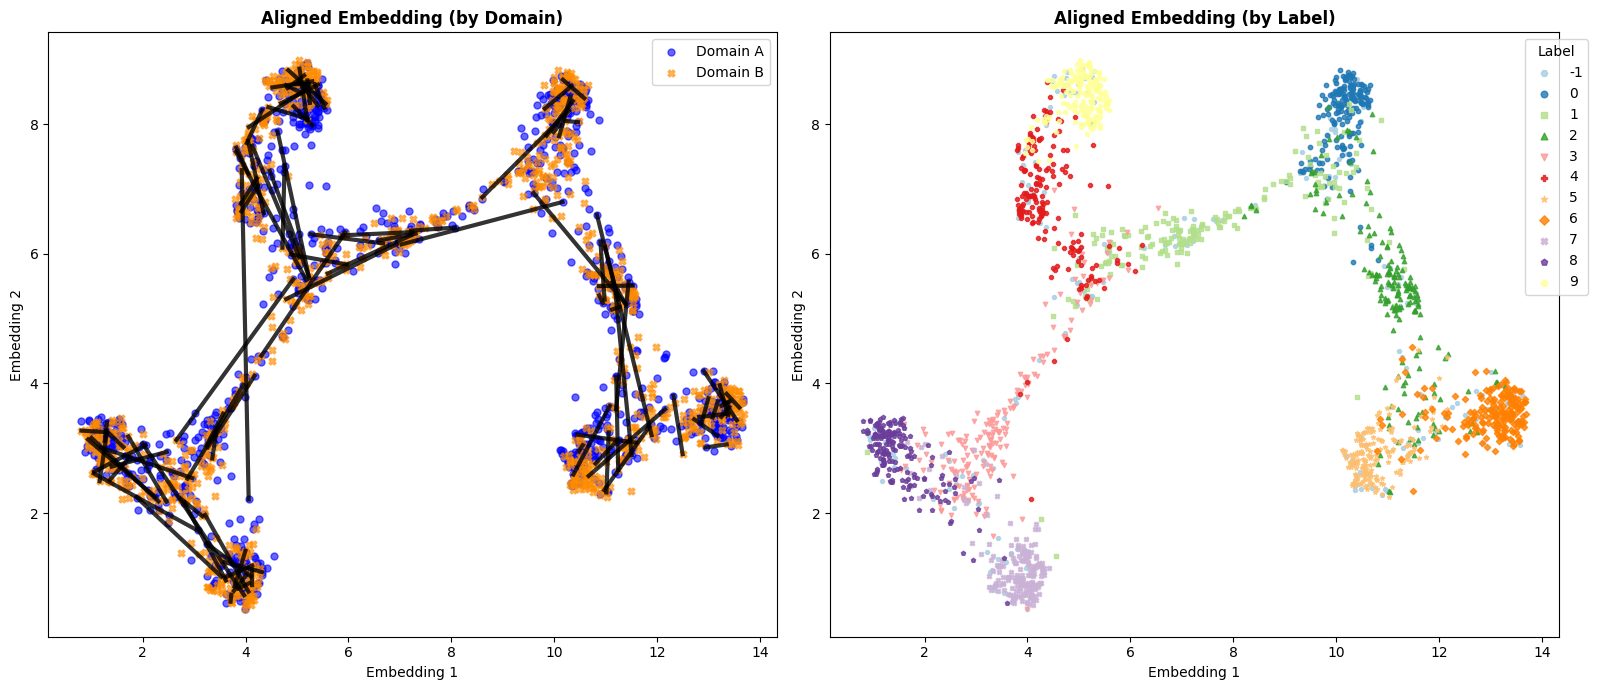


--- Quantitative Evaluation ---
1. Label Preservation (k-NN Accuracy):
  k-NN Accuracy on embedding: 0.7820 (Ideal: High)

2. Label Preservation (Silhouette Score):
  Silhouette Score (by Label): 0.2854 (Ideal: High)

3. Domain Mixing (Silhouette Score):
  Silhouette Score (by Domain): -0.0006 (Ideal: Low)

--- Interpretation ---
A good alignment shows:
  - High k-NN Acc & high Label Silhouette (labels are well-separated)
  - Low Domain Silhouette (domains are well-mixed)


In [7]:

# ------------------------------------
# VISUALIZATION (Dataset-Agnostic)
# ------------------------------------
print("\n--- Visualization ---")
print("Generating plots (color-blind friendly)...")

labels_combined = np.concatenate([y_source, y_target]).astype(int)

# Generic domain names
domains_combined = np.concatenate([
    np.full(len(y_source), "Domain A"),
    np.full(len(y_target), "Domain B")
])

plt.figure(figsize=(16, 7))

# --- Plot 1: Colored by Domain ---
plt.subplot(1, 2, 1)

domain_viz = {
    "Domain A": {'color': 'blue', 'marker': 'o'},
    "Domain B": {'color': 'darkorange', 'marker': 'X'}
}

for domain in np.unique(domains_combined):
    idx = (domains_combined == domain)
    plt.scatter(
        embedding[idx, 0], embedding[idx, 1],
        c=domain_viz[domain]['color'],
        marker=domain_viz[domain]['marker'],
        label=domain,
        alpha=0.6, s=25
    )

# === OPTIONAL: TRUE MATCHING LINES (only if T_true exists) ===
if ('T_true' in globals()) and (T_true is not None):
    print("Plotting TRUE matchings (T_true).")

    T_vis = T_true
    if sparse.issparse(T_vis):
        T_vis = T_vis.A

    n_a = len(y_source)
    n_b = len(y_target)

    if T_vis.shape != (n_a, n_b):
        raise ValueError(f"T_true shape mismatch: expected {(n_a,n_b)}, got {T_vis.shape}")

    # Normalize rows
    row_sums = T_vis.sum(axis=1, keepdims=True) + 1e-12
    T_norm = T_vis / row_sums

    N_LINKS = min(100, n_a)
    subset_A = np.random.choice(n_a, size=N_LINKS, replace=False)

    for i in subset_A:
        j = np.argmax(T_norm[i])
        x1, y1 = embedding[i]
        x2, y2 = embedding[n_a + j]

        plt.plot([x1, x2], [y1, y2],
                 color="k", alpha=0.8, linewidth=3)

else:
    print("No T_true provided → skipping matching-line overlay.")

plt.title("Aligned Embedding (by Domain)", fontweight="bold")
plt.legend()
plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")

# --- Plot 2: Colored by Label ---
plt.subplot(1, 2, 2)

cmap_10_safe = plt.get_cmap("Paired")
markers_10 = ['o', 's', '^', 'v', 'P', '*', 'D', 'X', 'p', 'H']

unique_labels = np.unique(labels_combined)

for i, label in enumerate(unique_labels):
    idx = (labels_combined == label)
    marker_idx = label % len(markers_10)
    
    plt.scatter(
        embedding[idx, 0], embedding[idx, 1],
        color=cmap_10_safe(i / len(unique_labels)),
        marker=markers_10[marker_idx],
        label=str(label),
        alpha=0.8, s=10
    )

plt.title("Aligned Embedding (by Label)", fontweight="bold")
plt.legend(title="Label", markerscale=1.5, bbox_to_anchor=(1.05, 1))
plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")

plt.tight_layout()
plt.show()

# ------------------------------------
# QUANTITATIVE EVALUATION
# ------------------------------------
print("\n--- Quantitative Evaluation ---")

# 1. Label Preservation (k-NN Accuracy)
print("1. Label Preservation (k-NN Accuracy):")
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(embedding, labels_combined)
y_pred = knn.predict(embedding)
knn_acc = accuracy_score(labels_combined, y_pred)
print(f"  k-NN Accuracy on embedding: {knn_acc:.4f} (Ideal: High)")

# 2. Label Silhouette
print("\n2. Label Preservation (Silhouette Score):")
label_sil = silhouette_score(embedding, labels_combined)
print(f"  Silhouette Score (by Label): {label_sil:.4f} (Ideal: High)")

# 3. Domain Mixing Silhouette
print("\n3. Domain Mixing (Silhouette Score):")
domain_sil = silhouette_score(embedding, domains_combined)
print(f"  Silhouette Score (by Domain): {domain_sil:.4f} (Ideal: Low)")

print("\n--- Interpretation ---")
print("A good alignment shows:")
print("  - High k-NN Acc & high Label Silhouette (labels are well-separated)")
print("  - Low Domain Silhouette (domains are well-mixed)")

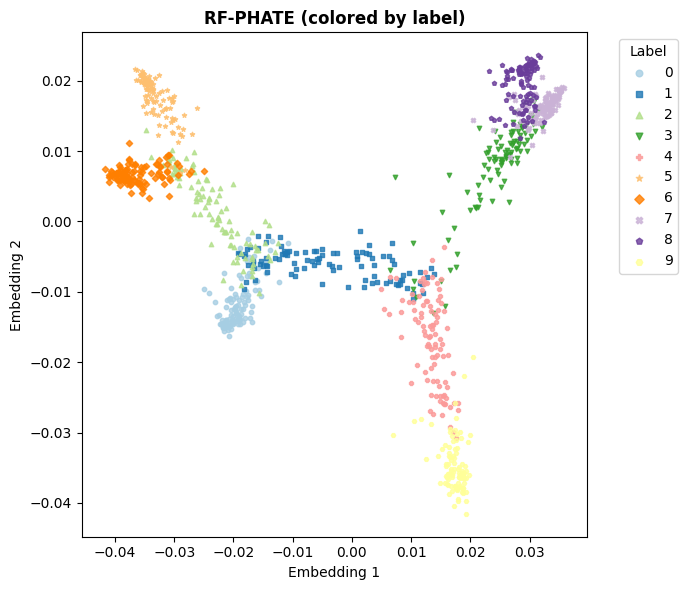

Semi-supervised mode. Forcing `non_zero_diagonal`=True and `force_symmetric`=True for consistency.
    SGD-MDS may not have converged: stress changed by 1.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.


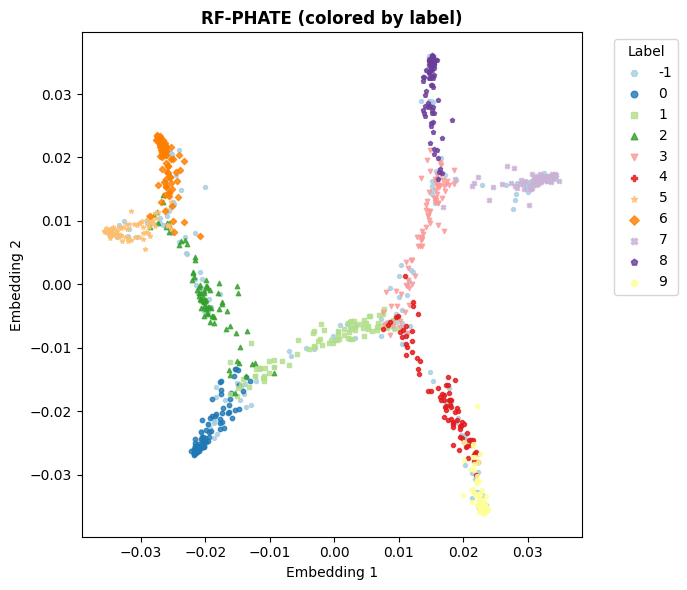

In [8]:
def plot_rfphate_labels(z, y, title="RF-PHATE (colored by label)"):
    """
    z : (n_samples, 2) RF-PHATE embedding
    y : label array (ints)
    """

    import numpy as np
    import matplotlib.pyplot as plt

    z = np.asarray(z)
    y = np.asarray(y)

    # --- Same color map & markers as your existing block ---
    cmap_10_safe = plt.get_cmap("Paired")
    markers_10 = ['o', 's', '^', 'v', 'P', '*', 'D', 'X', 'p', 'H']

    unique_labels = np.unique(y)

    plt.figure(figsize=(7, 6))

    for i, label in enumerate(unique_labels):
        idx = (y == label)
        marker_idx = label % len(markers_10)

        plt.scatter(
            z[idx, 0], z[idx, 1],
            color=cmap_10_safe(i / len(unique_labels)),
            marker=markers_10[marker_idx],
            alpha=0.8,
            s=10,
            label=str(label)
        )

    plt.title(title, fontweight="bold")
    plt.xlabel("Embedding 1")
    plt.ylabel("Embedding 2")
    plt.legend(title="Label", markerscale=1.5, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


rfp = RFPHATE(n_components=2, beta=0.5, random_state=42)
z = rfp.fit_transform(x_source, y_source)   # X: your dataset
plot_rfphate_labels(z, y_source)
# phate = PHATE(n_components=2)
# z = phate.fit_transform(x_source)   # X: your dataset
# plot_rfphate_labels(z, y_source, title="PHATE (colored by label)")

z = rfp.fit_transform(x_target, y_target)   # X: your dataset
plot_rfphate_labels(z, y_target)